# Figure 2

Sample-level data — missingness, cancer-group case counts, molecular subtype × cancer-group alignment

2.A
N = 4312 samples | RNA_LIBRARY_SELECTION 42.5% (1834), TUMOR_FRACTION 33.3% (1435), TUMOR_PLOIDY 31.9% (1374), SAMPLE_TYPE 23.7% (1023), MATCHED_NORMAL_SPECIMEN_ID 22.0% (949), MATCHED_NORMAL_SAMPLE_ID 22.0% (949), MOLECULAR_SUBTYPE 20.5% (882)
Missing > 0:
RNA_LIBRARY_SELECTION            42.5
TUMOR_FRACTION                   33.3
TUMOR_PLOIDY                     31.9
SAMPLE_TYPE                      23.7
MATCHED_NORMAL_SPECIMEN_ID       22.0
MATCHED_NORMAL_SAMPLE_ID         22.0
MOLECULAR_SUBTYPE                20.5
ONCOTREE_CODE                    19.9
EXTENT_OF_TUMOR_RESECTION         7.2
CANCER_TYPE                       6.9
CANCER_GROUP                      5.5
CNS_REGION                        3.1
CANCER_TYPE_DETAILED              2.9
PATHOLOGY_FREE_TEXT_DIAGNOSIS     2.8
BROAD_HISTOLOGY                   1.1


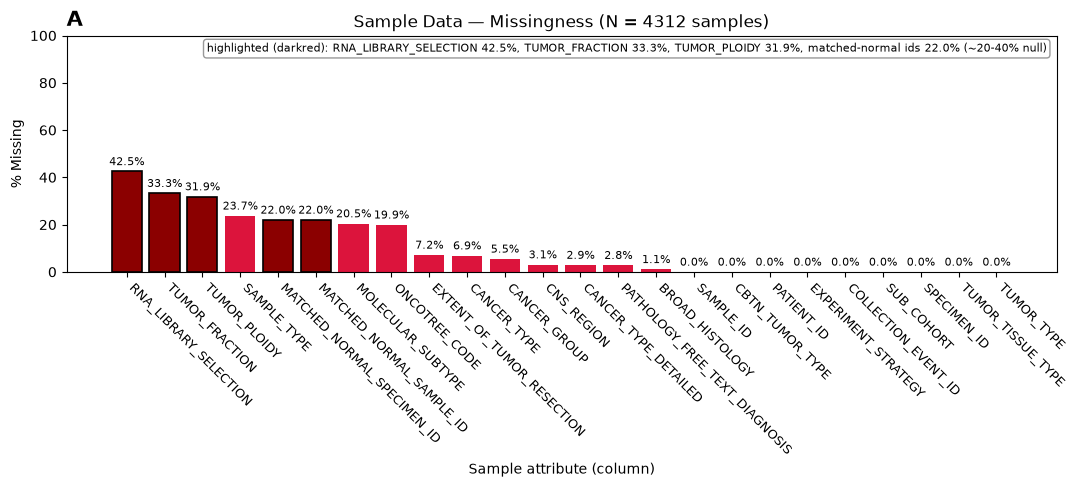

In [1]:
# Panel 2.A — Sample Data: Missingness  (context/figure_instructions/fig_samples_data.md)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- data: self-contained (no cleaning needed for missingness) ---
SAMPLE_FILE = "../../PBTA_RNA/data_clinical_sample_attributes.txt"
df = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
N = len(df)  # 4312

# --- computation: % null per column, sorted descending ---
miss = df.isna().mean().sort_values(ascending=False) * 100
nulls = df.isna().sum().reindex(miss.index)
highlight = {"TUMOR_FRACTION", "TUMOR_PLOIDY", "RNA_LIBRARY_SELECTION",
             "MATCHED_NORMAL_SAMPLE_ID", "MATCHED_NORMAL_SPECIMEN_ID"}

# --- exact values from fig_samples_data.md Panel A spec (assert so mismatches are visible) ---
assert N == 4312
spec = {"RNA_LIBRARY_SELECTION": 42.5, "TUMOR_FRACTION": 33.3, "TUMOR_PLOIDY": 31.9,
        "SAMPLE_TYPE": 23.7, "MATCHED_NORMAL_SPECIMEN_ID": 22.0, "MATCHED_NORMAL_SAMPLE_ID": 22.0,
        "MOLECULAR_SUBTYPE": 20.5, "ONCOTREE_CODE": 19.9, "EXTENT_OF_TUMOR_RESECTION": 7.2,
        "CANCER_TYPE": 6.9, "CANCER_GROUP": 5.5, "CNS_REGION": 3.1,
        "CANCER_TYPE_DETAILED": 2.9, "PATHOLOGY_FREE_TEXT_DIAGNOSIS": 2.8, "BROAD_HISTOLOGY": 1.1}
for col, pct in spec.items():
    assert abs(miss[col] - pct) < 0.05, (col, miss[col])
assert (miss == 0).sum() == 9  # 9 identity/metadata columns at 0.0%

print("2.A")
print("N =", N, "samples |", ", ".join("%s %.1f%% (%d)" % (c, miss[c], int(nulls[c]))
      for c in ["RNA_LIBRARY_SELECTION", "TUMOR_FRACTION", "TUMOR_PLOIDY", "SAMPLE_TYPE",
                "MATCHED_NORMAL_SPECIMEN_ID", "MATCHED_NORMAL_SAMPLE_ID", "MOLECULAR_SUBTYPE"]))
print("Missing > 0:")
print(miss[miss > 0].round(1).to_string())

# --- plot: vertical bar; highlight the 5 text-called-out columns (crimson, darkred + outline) ---
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["darkred" if c in highlight else "crimson" for c in miss.index]
edges = ["black" if c in highlight else "none" for c in miss.index]
ax.bar(range(len(miss)), miss.values, color=colors, edgecolor=edges, linewidth=1.2)
ax.set_xticks(range(len(miss)))
ax.set_xticklabels(miss.index, rotation=-45, ha="left", fontsize=9)
ax.set_xlabel("Sample attribute (column)")
ax.set_ylabel("% Missing")
ax.set_ylim(0, 100)
ax.set_title("Sample Data — Missingness (N = %d samples)" % N)
for i, v in enumerate(miss.values):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
ax.text(0.99, 0.97, "highlighted (darkred): RNA_LIBRARY_SELECTION 42.5%, TUMOR_FRACTION 33.3%, "
        "TUMOR_PLOIDY 31.9%, matched-normal ids 22.0% (~20-40% null)",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round", fc="white", ec="0.6"))
ax.text(0.0, 1.02, "A", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


2.B
N = 4312 samples | 4074 with CANCER_GROUP (238 missing, 5.5%) | 55 cancer groups total
Top-12 counts: {'Low-grade glioma': 862, 'High-grade glioma': 512, 'Medulloblastoma': 440, 'Diffuse midline glioma': 421, 'Ependymoma': 341, 'Atypical Teratoid Rhabdoid Tumor': 152, 'Ganglioglioma': 151, 'Adamantinomatous Craniopharyngioma': 115, 'Meningioma': 100, 'Choroid plexus tumor': 100, 'Dysembryoplastic neuroepithelial tumor': 73, 'Oligodendroglioma': 70}


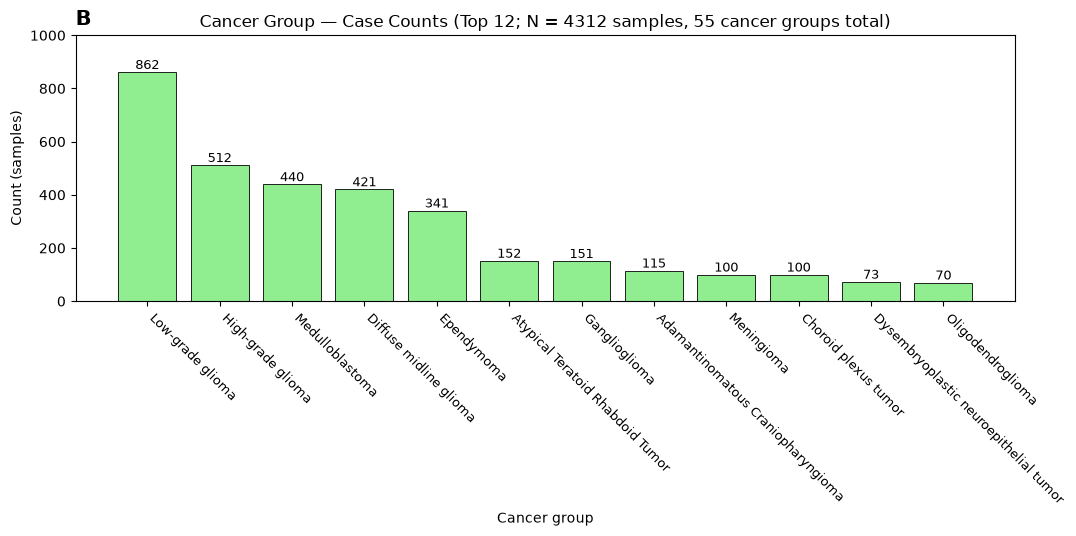

In [2]:
# Panel 2.B — Cancer Group: Case Counts (Top 12)  (context/figure_instructions/fig_samples_data.md)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- data: self-contained ---
SAMPLE_FILE = "../../PBTA_RNA/data_clinical_sample_attributes.txt"
df = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
N = len(df)  # 4312

# --- computation: top-12 cancer groups, value_counts() descending order ---
cg_vc = df["CANCER_GROUP"].value_counts()        # dropna by default -> 4074 samples with a CG
top = cg_vc.head(12)
n_total_cg = df["CANCER_GROUP"].nunique()        # 55

# --- exact values from fig_samples_data.md Panel B spec (assert so mismatches are visible) ---
expected = {"Low-grade glioma": 862, "High-grade glioma": 512, "Medulloblastoma": 440,
            "Diffuse midline glioma": 421, "Ependymoma": 341,
            "Atypical Teratoid Rhabdoid Tumor": 152, "Ganglioglioma": 151,
            "Adamantinomatous Craniopharyngioma": 115, "Meningioma": 100,
            "Choroid plexus tumor": 100, "Dysembryoplastic neuroepithelial tumor": 73,
            "Oligodendroglioma": 70}
for cg, cnt in expected.items():
    assert cg_vc[cg] == cnt, (cg, cg_vc[cg], cnt)
assert n_total_cg == 55
assert list(top.index) == list(expected.keys())  # top-12 ORDER = value_counts descending

print("2.B")
print("N = %d samples | %d with CANCER_GROUP (%d missing, %.1f%%) | %d cancer groups total" % (
    N, int(cg_vc.sum()), int(df["CANCER_GROUP"].isna().sum()),
    df["CANCER_GROUP"].isna().mean() * 100, n_total_cg))
print("Top-12 counts:", {c: int(v) for c, v in top.items()})

# --- plot: lightgreen vertical bar, value labels above ---
fig, ax = plt.subplots(figsize=(11, 5.5))
b = ax.bar(top.index, top.values, color="lightgreen", edgecolor="black", linewidth=0.6)
ax.bar_label(b, label_type="edge", fontsize=9)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=-45, ha="left", fontsize=9)
ax.set_xlabel("Cancer group")
ax.set_ylabel("Count (samples)")
ax.set_ylim(0, 1000)
ax.set_title("Cancer Group — Case Counts (Top 12; N = %d samples, %d cancer groups total)" % (
    N, n_total_cg))
ax.text(0.0, 1.02, "B", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


2.C
N = 4312 samples total; 4074 with a CANCER_GROUP (of 4312); 13 subtypes present in >=2 distinct CGs
Subtype — total (with CG) — distinct CGs:
  Unclassified — 882 (644) — 26  [26 CGs]
  LGG, To be classified — 81 (81) — 3  [Low-grade glioma, Pilocytic astrocytoma, Pleomorphic xanthoastrocytoma]
  HGG, To be classified — 33 (33) — 4  [Astroblastoma, Astrocytoma, Diffuse intrinsic pontine glioma, High-grade glioma]
  GNT, wildtype — 17 (17) — 2  [Desmoplastic infantile astrocytoma and ganglioglioma, Glial-neuronal tumor NOS]
  NBL, To be classified — 17 (17) — 2  [Ganglioneuroblastoma, Neuroblastoma]
  GNT, FGFR — 14 (14) — 2  [Glial-neuronal tumor NOS, Rosette-forming glioneuronal tumor]
  GNT, BRAF V600E — 13 (13) — 2  [Desmoplastic infantile astrocytoma and ganglioglioma, Glial-neuronal tumor NOS]
  GNT, RTK — 9 (9) — 2  [Desmoplastic infantile astrocytoma and ganglioglioma, Glial-neuronal tumor NOS]
  SEGA, wildtype — 9 (9) — 2  [Low-grade glioma, Subependymal Giant Cell Astrocyt

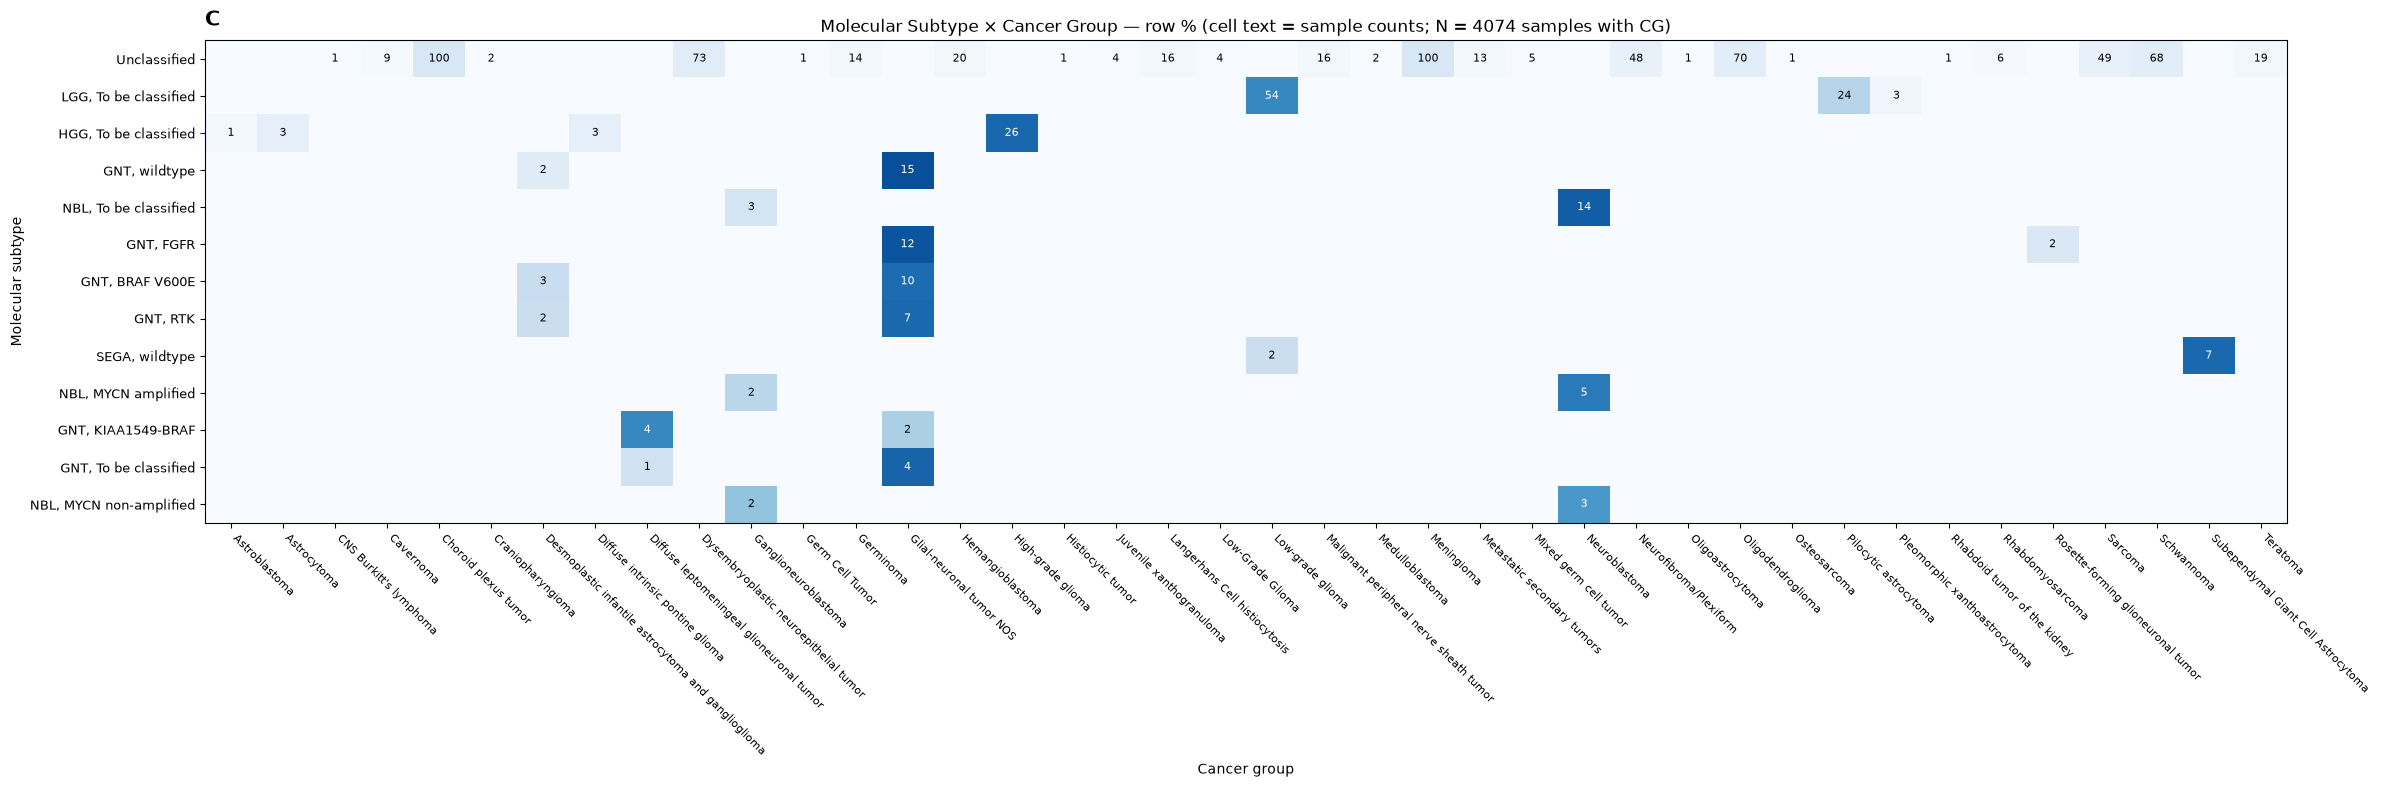

In [3]:
# Panel 2.C — Molecular Subtype × Cancer Group (13 multi-CG subtypes)  (context/figure_instructions/fig_samples_data.md)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- data: self-contained + clean_subtype() (blank + "To be classified" -> "Unclassified") ---
SAMPLE_FILE = "../../PBTA_RNA/data_clinical_sample_attributes.txt"
df = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
N = len(df)  # 4312
df["MOLECULAR_SUBTYPE"] = df["MOLECULAR_SUBTYPE"].fillna("Unclassified")
df["MOLECULAR_SUBTYPE"] = df["MOLECULAR_SUBTYPE"].replace("To be classified", "Unclassified")

# --- computation: subtype x CANCER_GROUP crosstab; 13 subtypes present in >=2 distinct CGs ---
ct = pd.crosstab(df["MOLECULAR_SUBTYPE"], df["CANCER_GROUP"])     # 133 subtypes x 55 CGs
n_distinct_cg = (ct > 0).sum(axis=1)                              # distinct CGs each subtype touches
rows = sorted(n_distinct_cg[n_distinct_cg >= 2].index,
              key=lambda s: (-int(ct.loc[s].sum()), s))           # 13 subtypes, total-desc order
cols = sorted({cg for s in rows for cg in ct.columns if ct.loc[s, cg] > 0})  # CGs the 13 touch
cf = ct.loc[rows, cols]                                           # 13 x 40
cn = cf.div(cf.sum(axis=1), axis=0).fillna(0)                     # row proportion (row %)

# --- exact values from fig_samples_data.md Panel C spec (assert so mismatches are visible) ---
spec = {  # subtype: (total samples, samples with CG, distinct CGs)
    "Unclassified": (882, 644, 26), "LGG, To be classified": (81, 81, 3),
    "HGG, To be classified": (33, 33, 4), "GNT, wildtype": (17, 17, 2),
    "NBL, To be classified": (17, 17, 2), "GNT, FGFR": (14, 14, 2),
    "GNT, BRAF V600E": (13, 13, 2), "GNT, RTK": (9, 9, 2),
    "SEGA, wildtype": (9, 9, 2), "NBL, MYCN amplified": (7, 7, 2),
    "GNT, KIAA1549-BRAF": (6, 6, 2), "GNT, To be classified": (5, 5, 2),
    "NBL, MYCN non-amplified": (5, 5, 2),
}
sub_vc = df["MOLECULAR_SUBTYPE"].value_counts()
for s, (tot, wcg, nc) in spec.items():
    assert int(sub_vc[s]) == tot, (s, "total", int(sub_vc[s]), tot)
    assert int(cf.loc[s].sum()) == wcg, (s, "withCG", int(cf.loc[s].sum()), wcg)
    assert int((cf.loc[s] > 0).sum()) == nc, (s, "nCG", int((cf.loc[s] > 0).sum()), nc)
assert len(rows) == 13
assert int(sub_vc.reindex(rows).sum()) == 1098    # sum of subtype totals
assert int(cf.values.sum()) == 860                # sum of samples with a CG

print("2.C")
print("N = %d samples total; %d with a CANCER_GROUP (of %d); 13 subtypes present in >=2 distinct CGs" % (
    N, int(df["CANCER_GROUP"].notna().sum()), N))
print("Subtype — total (with CG) — distinct CGs:")
for s in rows:
    tot, wcg, nc = int(sub_vc[s]), int(cf.loc[s].sum()), int((cf.loc[s] > 0).sum())
    cg_list = ", ".join(cf.columns[cf.loc[s] > 0]) if nc <= 4 else "%d CGs" % nc
    print("  %s — %d (%d) — %d  [%s]" % (s, tot, wcg, nc, cg_list))
print("Sum: %d total / %d with CG" % (int(sub_vc.reindex(rows).sum()), int(cf.values.sum())))

# --- plot: heatmap, cell text = counts, cell color = row proportion (row %) ---
fig, ax = plt.subplots(figsize=(24, 8))
im = ax.imshow(cn.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
for r in range(cf.shape[0]):
    for c in range(cf.shape[1]):
        v = int(cf.values[r, c])
        if v == 0:
            continue
        ax.text(c, r, str(v), ha="center", va="center", fontsize=8,
                color="white" if cn.values[r, c] > 0.55 else "black")
ax.set_xticks(range(cf.shape[1]))
ax.set_xticklabels(cf.columns, rotation=-45, ha="left", fontsize=8)
ax.set_yticks(range(cf.shape[0]))
ax.set_yticklabels(cf.index, fontsize=9)
ax.set_xlabel("Cancer group")
ax.set_ylabel("Molecular subtype")
ax.set_title("Molecular Subtype × Cancer Group — row %% (cell text = sample counts; "
             "N = %d samples with CG)" % int(df["CANCER_GROUP"].notna().sum()))
ax.text(0.0, 1.02, "C", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()
